In [33]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Any, Dict
import operator
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_community.tools.tavily_search import TavilySearchResults
#from langchain_tavily_search import TavilySearch obsolete
from langchain_community.tools.tavily_search import TavilySearchResults as TavilySearch
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from dataclasses import dataclass, field

In [34]:
import google.generativeai as genai
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

In [35]:
from uuid import uuid4

def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:

    for message in right:
        if not message.id:
            message.id = str(uuid4())
    
    merged = left.copy()
    for message in right:
        for i, existing in enumerate(merged):
            if existing.id == message.id:
                merged[i] = message
                break
        else:
            merged.append(message)
    return merged

In [36]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]

In [37]:
from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage, ToolMessage
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage

class Agent:

    def __init__(self, model, tools, system="", checkpointer=None):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges("llm", self.exists_action, {True: "action", False: END})
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile(
            checkpointer=checkpointer,
            interrupt_before=["action"] # Añade una interrupción antes de llamar una acción
        )
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)
    
    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}
    
    def exists_action(self, state: AgentState):
        print(state)
        result = state['messages'][-1]
        return len(result.tool_calls) > 0
    
    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Llamando la herramienta: {t['name']} con los siguientes argumentos: {t['args']}")
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Retornando al modelo!")
        return {'messages': results}

In [38]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y")

prompt = f"""Eres un asistente de investigación inteligente y altamente actualizado. \
Tu prioridad principal es encontrar la información más RECIENTE y en TIEMPO REAL siempre que sea posible. \
La fecha actual es {current_date}. \
Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", \
DEBES **incluir la fecha actual ({current_date}) en tu consulta a la herramienta de búsqueda**. \
Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x {current_date}". \
Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre el "hoy" o el "ahora". \
Utiliza el mecanismo de búsqueda para buscar información, siempre priorizando el "hoy" o el "ahora". \
Tienes permiso para realizar múltiples llamadas (ya sea de forma conjunta o en secuencia). \
Busca información solo cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo! \
"""

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
tool = TavilySearchResults(max_results=3)
abot = Agent(model, [tool], system=prompt, checkpointer=memory)

In [39]:
import uuid

session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando una nueva conversación con el ID: {session_id}\n")

user_message = "Cómo está el clima en Pereira hoy?"
messages = [HumanMessage(content=user_message)]
thread_config = {"configurable": {"thread_id": session_id}}

print(f"--- Etapa 1: El agente procesa la entrada y decide la acción ---")
print(f"Usted: {user_message}")

for event in abot.graph.stream({"messages": messages}, thread_config):
    for k, v in event.items():
        if k == "llm":
            last_message = v.get('messages', [])[-1]
            if isinstance(last_message, AIMessage) and last_message.tool_calls:
                print(f"\nAgente (decisión): {last_message.tool_calls}")
                print(f"\n--- AGENTE PAUSADO: Intervención humana requerida ---")
            else:
                print(f"\nAgente (respuesta directa/sin tool_calls): {last_message.content}")
                print(f"\n--- AGENTE PAUSADO (respuesta directa, sin acción pendiente) ---")

DEBUG: Iniciando una nueva conversación con el ID: 426c09ff-6c7e-454f-865f-4d57dabdd202

--- Etapa 1: El agente procesa la entrada y decide la acción ---
Usted: Cómo está el clima en Pereira hoy?
{'messages': [HumanMessage(content='Cómo está el clima en Pereira hoy?', additional_kwargs={}, response_metadata={}, id='ce145c4e-8ff3-4a4a-8fa9-6ac7253fafca'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Pereira 17/07/2026"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f71d9-27e3-77b3-9cbc-7b6fd756d175-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereira 17/07/2026'}, 'id': '53fd8849-04df-441d-98f2-d96ccf086e86', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 321, 'output_tokens': 35, 'total_tokens': 356, 'input_token_details':

In [40]:
current_state = abot.graph.get_state(thread_config)
last_state_message = current_state.values['messages'][-1]

if current_state and current_state.next == ('action',) and isinstance(last_state_message, AIMessage) and last_state_message.tool_calls:
    tool_calls_pending = last_state_message.tool_calls
    if tool_calls_pending:
        print(f"\nEl agente decidió ejecutar la(s) siguiente(s) acción(es) de herramienta:")
        for tc in tool_calls_pending:
            print(f"- Herramienta: {tc['name']}, Argumentos: {tc['args']}")

    user_input = input("\nDesea que el agente ejecute la(s) acción(es)? (si/no): ").lower()

    if user_input == 'si':
        print("\n--- Etapa 2: Retomando la ejecución (Agente ejecutará la acción) ---")
        for event in abot.graph.stream(None, thread_config):
            for k, v in event.items():
                if k == "action":
                    print(f"DEBUG: Herramienta ejecutada y resultado retornado: {v}")
                elif k == "llm":
                    final_response_message = v.get('messages',[])[-1].content
                    print(f"\nAgente (respuesta final): {final_response_message}")
                elif k == "__end__":
                    print(f"DEBUG: El grafo terminó la ejecución.")
        print("\n--- FIN DE LA INTERACCIÓN ---")
    else:
        print("\nEjecución de la acción cancelada por el usuario.")
        print("\n--- FIN DE LA INTERACCIÓN ---")
else:
    print("\nEl agente no decidió ninguna acción de herramienta a pesar de la pausa. Interacción finalizada.")
    if current_state:
        final_response_message = current_state.values['messages'][-1].content
        print(f"Agente (respuesta directa): {final_response_message}")
    print("\n--- FIN DE LA INTERACCIÓN ---")


El agente decidió ejecutar la(s) siguiente(s) acción(es) de herramienta:
- Herramienta: tavily_search_results_json, Argumentos: {'query': 'clima en Pereira 17/07/2026'}

--- Etapa 2: Retomando la ejecución (Agente ejecutará la acción) ---
Llamando la herramienta: tavily_search_results_json con los siguientes argumentos: {'query': 'clima en Pereira 17/07/2026'}
Retornando al modelo!
DEBUG: Herramienta ejecutada y resultado retornado: {'messages': [ToolMessage(content="[{'title': 'Archivo de tiempo en Pereira durante la última semana, el tiempo en Pereira en julio 2026 año', 'url': 'https://www.weatherandclimate.info/sp/weather/80210', 'content': '| vrb | 1 | 15 km | 10/3 600 m [Cu hum As trans] | +27.2 | +20.8 | 68 | +34 | +40 | muy sofocante | 866.5 |\\n| calm | 0 | 10 km | llovizna débil | 10/4 540 m [Cu med, cong As trans] | +27.3 | +17.8 | 56 | +32 | +33 | muy sofocante | 865.5 |\\n| E | 3 | 15 km | 9/3 540 m [Sc As trans Cs] | +20.1 | +17.4 | 84 | +23 | +24 | confort | 867.5 | +19


--- Tratando genterar el PNG del Grafo via Mermaid ---


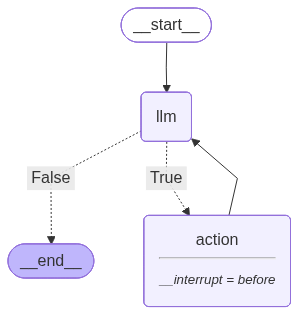

In [41]:
from IPython.display import Image, display

print("\n--- Tratando genterar el PNG del Grafo via Mermaid ---")
try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except AttributeError:
    print("Método .draw_mermaid_png() no encontrado o sin soporte.")
    print("Tratando generar únicamente el código Mermaid...")
    try:
        mermaid_code = abot.graph.get_graph().draw_mermaid()
        print(f"\n--- Código Mermaid Generado (Pegado en https://mermaid.live/) ---")
        print(mermaid_code)
    except Exception as e_mermaid:
        print(f"Error al generar el código Mermaid: {e_mermaid}")
except Exception as e:
    print(f"Error inesperado al tratar generar el grafo: {e}")

In [42]:
from IPython.display import Image, display
import uuid

new_session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando una nueva conversación con ID: {new_session_id}\n")
new_user_message = "Cuál es la distancia entre CDMX y Tokio?"
new_messages = [HumanMessage(content=new_user_message)]
new_thread_config = {"configurable": {"thread_id": new_session_id}}

print("--- Iniciando Nueva Interacción: Agente procesa la entrada y recibe la acción ---")
print(f"Usted: {new_user_message}")
print(f"DEBUG: ID del nuevo hilo: {new_session_id}")

print("\n--- Agente pensando y pausando ---")
try:
    for event in abot.graph.stream({"messages": new_messages}, new_thread_config):
        for k, v in event.items():
            if k == "llm":
                if v and 'messages' in v and v['messages']:
                    llm_message_from_event = v['messages'][0]
                    if hasattr(llm_message_from_event, 'tool_calls') and llm_message_from_event.tool_calls:
                        print(f"nAgente (decisión): {llm_message_from_event.tool_calls}")
                        print("\n--- AGENTE PAUSADO: Intervención humana necesaria ---")
                    
                    elif llm_message_from_event.content:
                        print(f"\nAgente (respuesta directa): {llm_message_from_event.content}")
                        print("\n--- AGENTE NO PAUSÓ POR LA HERRAMIENTA (Respuesta directa de la LLM) ---")

except Exception as e:
    print(f"DEBUG: Stream interrumpido como esperado: {e}")

DEBUG: Iniciando una nueva conversación con ID: a0e7bf51-c079-424f-ba5c-eb8199fff5df

--- Iniciando Nueva Interacción: Agente procesa la entrada y recibe la acción ---
Usted: Cuál es la distancia entre CDMX y Tokio?
DEBUG: ID del nuevo hilo: a0e7bf51-c079-424f-ba5c-eb8199fff5df

--- Agente pensando y pausando ---
{'messages': [HumanMessage(content='Cuál es la distancia entre CDMX y Tokio?', additional_kwargs={}, response_metadata={}, id='17ad2183-ba1b-4f8d-bd42-807988f6955d'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "distancia entre Ciudad de M\\u00e9xico y Tokio"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f71db-7638-7f62-8c84-b493767c672d-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'distancia entre Ciudad de México y Tokio'}, 'id': 'ef8b6a64-554d-41d8-8de0-3cc79

In [43]:
current_state_snapshot = abot.graph.get_state(new_thread_config)

if current_state_snapshot:
    print(f"\nDEBUG: Estado actual obtenido para el nuevo ID del hilo: {session_id1}")
    
    snapshot_thread_id = None
    snapshot_thread_ts = None
    
    if hasattr(current_state_snapshot, 'config') and isinstance(current_state_snapshot.config, dict):
        if 'configurable' in current_state_snapshot.config and isinstance(current_state_snapshot.config['configurable'], dict):
            if 'thread_id' in current_state_snapshot.config['configurable']:
                snapshot_thread_id = current_state_snapshot.config['configurable']['thread_id']
            if '__run_id' in current_state_snapshot.config['configurable']:
                snapshot_thread_ts = current_state_snapshot.config['configurable']['__run_id']
            elif 'thread_ts' in current_state_snapshot.config['configurable']:
                snapshot_thread_ts = current_state_snapshot.config['configurable']['thread_ts']
                
    if snapshot_thread_id is None:
        snapshot_thread_id = session_id1

    print(f"DEBUG: ID del Hilo (del snapshot): {snapshot_thread_id}")
    print(f"DEBUG: Timestamp del snapshot (thread_ts): {snapshot_thread_ts}")
    print(f"DEBUG: Mensajes en el snapshot (al momento de la pausa): {current_state_snapshot.values.get('messages')}")

    if current_state_snapshot.values and 'messages' in current_state_snapshot.values:
        last_msg_in_snapshot = current_state_snapshot.values['messages'][-1]
        print(f"DEBUG: Tipo del último mensaje en el snapshot para la inyección: {type(last_msg_in_snapshot)}")
        if hasattr(last_msg_in_snapshot, 'tool_calls') and last_msg_in_snapshot.tool_calls:
            print(f"DEBUG: Último mensaje en el snapshot CONTIENE tool_calls. LISTO PARA LA INYECCIÓN!")
        else:
            print(f"DEBUG: Último mensaje en el snapshot NO CONTIENE tool_calls o está vacío. ¡PROBLEMA EN LA PAUSA!")
        if current_state_snapshot.next != ():
            print(f"\n--- Agente pausado y listo para la intervención. ---")
        else:
            print(f"\n--- ATENCIÓN: El agente NO está pausado donde debería. El grafo puede haber finalizado. ---")
else:
    print(f"DEBUG: Ningún estado encontrado para el nuevo ID de hilo: {session_id1}. Verifique la configuración del hilo o si el agente pausó.")


DEBUG: Estado actual obtenido para el nuevo ID del hilo: b641eeee-3e8a-449e-840c-c191f5f185cb
DEBUG: ID del Hilo (del snapshot): a0e7bf51-c079-424f-ba5c-eb8199fff5df
DEBUG: Timestamp del snapshot (thread_ts): None
DEBUG: Mensajes en el snapshot (al momento de la pausa): [HumanMessage(content='Cuál es la distancia entre CDMX y Tokio?', additional_kwargs={}, response_metadata={}, id='17ad2183-ba1b-4f8d-bd42-807988f6955d'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "distancia entre Ciudad de M\\u00e9xico y Tokio"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f71db-7638-7f62-8c84-b493767c672d-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'distancia entre Ciudad de México y Tokio'}, 'id': 'ef8b6a64-554d-41d8-8de0-3cc795110322', 'type': 'tool_call'}], invalid_tool_calls=[], 

In [45]:
from langchain_core.messages import AIMessage

if current_state_snapshot:
    modified_state_values = current_state_snapshot.values.copy()
    final_injected_message = AIMessage(
        content="La distancia entre CDMX y Tokio es de aproximadamente 450 km. (Datos introducidos manualmente por usted!)"
    )

    ai_message_found = False
    for i, msg in enumerate(modified_state_values['messages']):
        if isinstance(msg, AIMessage):
            modified_state_values['messages'] = modified_state_values['messages'][:i] + [final_injected_message]
            ai_message_found = True
            break
    
    if not ai_message_found:
        modified_state_values['messages'].append(final_injected_message)
        print(f"\n--- Estado siendo MODIFICADO MANUALMENTE (Inyectando AIMessage Final) ---")
        print(f"DEBUG: Contenido del AIMessage falso inyectado: {final_injected_message.content}")
        print(f"DEBUG: Nueva lista de mensajes (últimos): {[m.type for m in modified_state_values['messages']][-2:]}")
else:
    print(f"DEBUG: No es posible modificar el estado porque ningún snapshot del estado fue encontrado.")

    print(f"\n--- Finalizando el estado con la respuesta inyectada ---")

    abot.graph.update_state(new_thread_config, modified_state_values)

    final_state_after_injection_obj = abot.graph.get_state(new_thread_config)
    print(f"\n--- Salida final del agente tras la intervención ---")

if hasattr(final_state_after_injection_obj, 'values') and isinstance(final_state_after_injection_obj.values, dict):
    final_messages = final_state_after_injection_obj.values['messages']
elif isinstance(final_state_after_injection_obj, dict):
    final_messages = final_state_after_injection_obj['messages']
else:
    found_messages_list = None
    if isinstance(final_state_after_injection_obj, tuple):
        for item in final_state_after_injection_obj:
            if isinstance(item, dict) and 'messages' in item:
                found_messages_list = item['messages']
                break
    elif isinstance(final_state_after_injection_obj, dict) and 'messages' in final_state_after_injection_obj:
        found_messages_list = final_state_after_injection_obj['messages']
    
    if found_messages_list is not None:
        final_messages = found_messages_list
    else:
        print(f"DEBUG: No fue posible extraer la lista de mensajes del estado del objeto al final: {final_state_after_injection_obj}")
        final_messages = []

if final_messages and isinstance(final_messages[-1], AIMessage):
    print(f"\nAgente: {final_messages[-1].content}")
else:
    print(f"\nAgente: Resposta final no fue encontrada o no es AIMessage.")
    print(f"DEBUG: Estado final completo (para inspección): {final_state_after_injection_obj}")

print(f"\n--- Flujo de Human-in-the-loop concluido ---")


Agente: La distancia entre CDMX y Tokio es de aproximadamente 450 km. (Datos introducidos manualmente por usted!)

--- Flujo de Human-in-the-loop concluido ---
